Лабораторная работа № 5.

In [30]:
import numpy as np
import pandas as pd
import seaborn as sns
sns.set_palette('husl')
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.model_selection import train_test_split
from sklearn import datasets
from sklearn.decomposition import PCA
from sklearn.decomposition import FastICA
from sklearn.manifold import TSNE
from sklearn.decomposition import KernelPCA
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

Подготовка датасета.

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
dataset = pd.read_csv('/content/drive/MyDrive/database_gas.csv')
print("Информация о датасете:")
dataset.head()

Информация о датасете:


,timestamp,temperature,humidity,CO2CosIRValue,CO2MG811Value,MOX1,MOX2,MOX3,MOX4,COValue
0,2019-11-06 11:37:13.038174+01:00,19.48,54.86,128.0,563.0,476.0,731.0,649.0,565.0,128.0
1,2019-11-06 11:37:32.744996+01:00,19.59,54.23,129.0,563.0,477.0,731.0,649.0,565.0,125.0
2,2019-11-06 11:37:53.018087+01:00,19.63,54.05,128.0,566.0,478.0,732.0,649.0,565.0,125.0
3,2019-11-06 11:38:13.093151+01:00,19.64,53.74,128.0,566.0,478.0,732.0,649.0,565.0,125.0
4,2019-11-06 11:38:33.032832+01:00,19.67,53.53,128.0,569.0,480.0,732.0,650.0,565.0,125.0


In [7]:
vals = dataset["timestamp"].unique()
vals

array(['2019-11-06 11:37:13.038174+01:00',
       '2019-11-06 11:37:32.744996+01:00',
       '2019-11-06 11:37:53.018087+01:00', ...,
       '2020-02-13 11:57:33.983249+01:00',
       '2020-02-13 11:57:54.058349+01:00',
       '2020-02-13 11:58:14.014336+01:00'], dtype=object)

In [8]:
cols_for_clusters = ['temperature','humidity','CO2CosIRValue','CO2MG811Value','MOX1','MOX2','MOX3','MOX4','COValue']
df= dataset[cols_for_clusters].copy()
df.head()

,temperature,humidity,CO2CosIRValue,CO2MG811Value,MOX1,MOX2,MOX3,MOX4,COValue
0,19.48,54.86,128.0,563.0,476.0,731.0,649.0,565.0,128.0
1,19.59,54.23,129.0,563.0,477.0,731.0,649.0,565.0,125.0
2,19.63,54.05,128.0,566.0,478.0,732.0,649.0,565.0,125.0
3,19.64,53.74,128.0,566.0,478.0,732.0,649.0,565.0,125.0
4,19.67,53.53,128.0,569.0,480.0,732.0,650.0,565.0,125.0


In [9]:
X = df
y, yvals = pd.factorize(dataset["timestamp"])
print(f"Уникальные классы: {yvals}")
print(f"Закодированные метки (первые 5): {y[:5]}")

Уникальные классы: Index(['2019-11-06 11:37:13.038174+01:00', '2019-11-06 11:37:32.744996+01:00',
       '2019-11-06 11:37:53.018087+01:00', '2019-11-06 11:38:13.093151+01:00',
       '2019-11-06 11:38:33.032832+01:00', '2019-11-06 11:38:52.976443+01:00',
       '2019-11-06 11:39:12.883211+01:00', '2019-11-06 11:39:32.839508+01:00',
       '2019-11-06 11:39:53.003425+01:00', '2019-11-06 11:40:12.986268+01:00',
       ...
       '2020-02-13 11:55:13.930613+01:00', '2020-02-13 11:55:33.951730+01:00',
       '2020-02-13 11:55:54.065586+01:00', '2020-02-13 11:56:14.043796+01:00',
       '2020-02-13 11:56:34.223559+01:00', '2020-02-13 11:56:53.929978+01:00',
       '2020-02-13 11:57:14.204458+01:00', '2020-02-13 11:57:33.983249+01:00',
       '2020-02-13 11:57:54.058349+01:00', '2020-02-13 11:58:14.014336+01:00'],
      dtype='object', length=416153)
Закодированные метки (первые 5): [0 1 2 3 4]


PCA (Анализ главных компонент).

/tmp/ipykernel_13300/946174568.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')


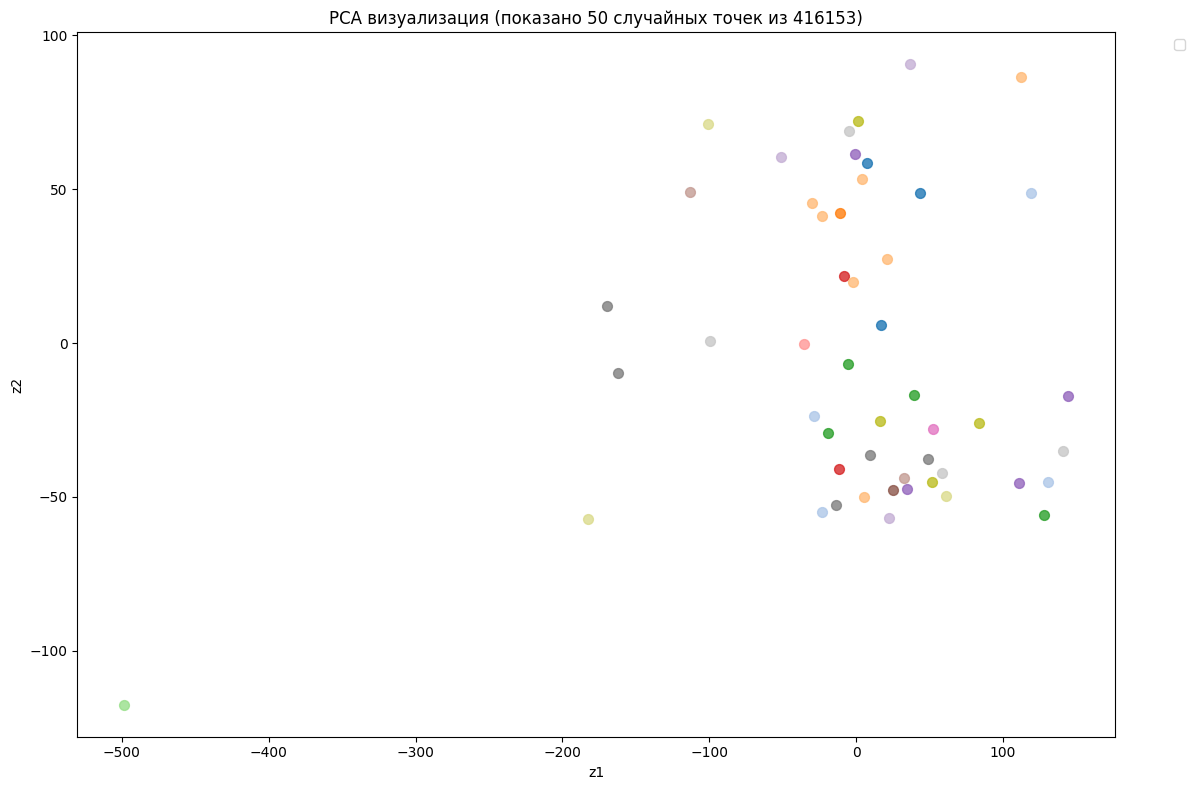

In [10]:
pca = PCA(n_components=8)
X_new = pca.fit(X).transform(X)
np.random.seed(42)
sample_indices = np.random.choice(len(X_new), size=50, replace=False)
plt.figure(figsize=(12,8))
for idx in sample_indices:
    plt.scatter(
        X_new[idx, 0],
        X_new[idx, 1],
        color=plt.cm.tab20(idx % 20),
        alpha=0.8,
        s=50,
        label=cols_for_clusters[idx] if idx < 50 else ""
    )
plt.xlabel("z1")
plt.ylabel("z2")
plt.title(f"PCA визуализация (показано 50 случайных точек из {len(X_new)})")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

Независисый анализ компонентов (Independent Component Analysis, ICA).

/tmp/ipykernel_13300/3340963575.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)


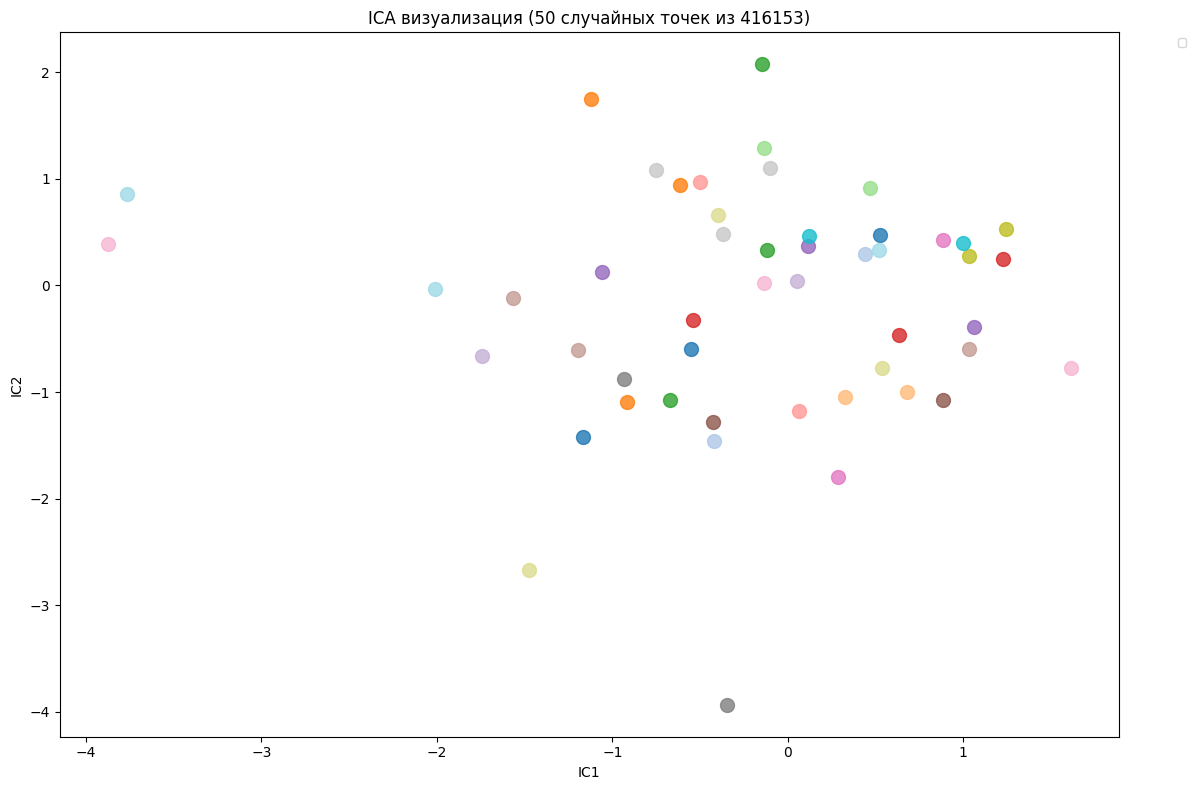

In [11]:
ica = FastICA(n_components=8, random_state=42)
X_new = ica.fit_transform(X)
plt.figure(figsize=(12,8))
np.random.seed(42)
n_samples = min(50, len(X_new))
sample_indices = np.random.choice(len(X_new), size=n_samples, replace=False)
colors = plt.cm.tab20(np.linspace(0, 1, n_samples))
for idx, sample_idx in enumerate(sample_indices):
    plt.scatter(
        X_new[sample_idx, 0],
        X_new[sample_idx, 1],
        color=colors[idx],
        alpha=0.8,
        s=100,
    )
plt.xlabel("IC1")
plt.ylabel("IC2")
plt.title(f"ICA визуализация ({n_samples} случайных точек из {len(X_new)})")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

Kernel PCA.

Тип X: <class 'pandas.core.frame.DataFrame'>
Размер X: (416153, 9)
Берем подвыборку из 1000 точек для Kernel PCA
Размер выборки: (1000, 9)
Вычисляем Kernel PCA...


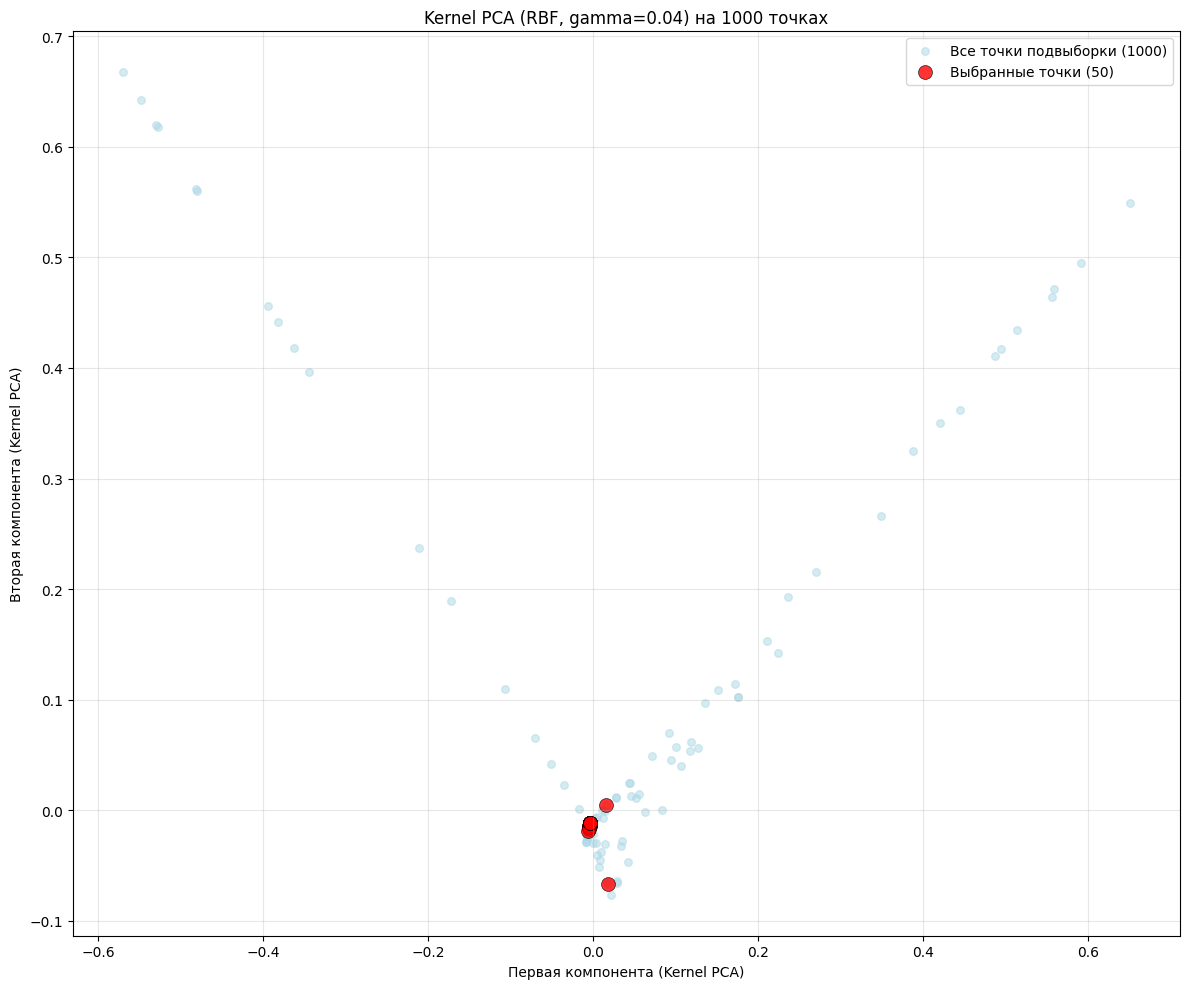

In [17]:
sample_size = min(1000, len(X))
print(f"Тип X: {type(X)}")
print(f"Размер X: {X.shape}")
print(f"Берем подвыборку из {sample_size} точек для Kernel PCA")
np.random.seed(42)
sample_indices = np.random.choice(len(X), size=sample_size, replace=False)
X_sample = X.iloc[sample_indices]
print(f"Размер выборки: {X_sample.shape}")
print("Вычисляем Kernel PCA...")
rbf_pca = KernelPCA(n_components=2, kernel='rbf', gamma=0.04)
X_new = rbf_pca.fit_transform(X_sample)
plt.figure(figsize=(12,10))
plt.scatter(
    X_new[:, 0],
    X_new[:, 1],
    c='lightblue',
    alpha=0.5,
    s=30,
    label=f'Все точки подвыборки ({sample_size})'
)
vis_indices = np.random.choice(len(X_new), size=min(50, len(X_new)), replace=False)
plt.scatter(
    X_new[vis_indices, 0],
    X_new[vis_indices, 1],
    c='red',
    alpha=0.8,
    s=100,
    label=f'Выбранные точки ({len(vis_indices)})',
    edgecolors='black',
    linewidth=0.5
)
plt.xlabel("Первая компонента (Kernel PCA)")
plt.ylabel("Вторая компонента (Kernel PCA)")
plt.title(f"Kernel PCA (RBF, gamma=0.04) на {sample_size} точках")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

tSNE.

Берем подвыборку из 1000 точек
Вычисляем t-SNE...
[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 1000 samples in 0.002s...
[t-SNE] Computed neighbors for 1000 samples in 0.050s...
[t-SNE] Computed conditional probabilities for sample 1000 / 1000
[t-SNE] Mean sigma: 16.562917


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


[t-SNE] KL divergence after 250 iterations with early exaggeration: 59.426449
[t-SNE] KL divergence after 1000 iterations: 0.513783


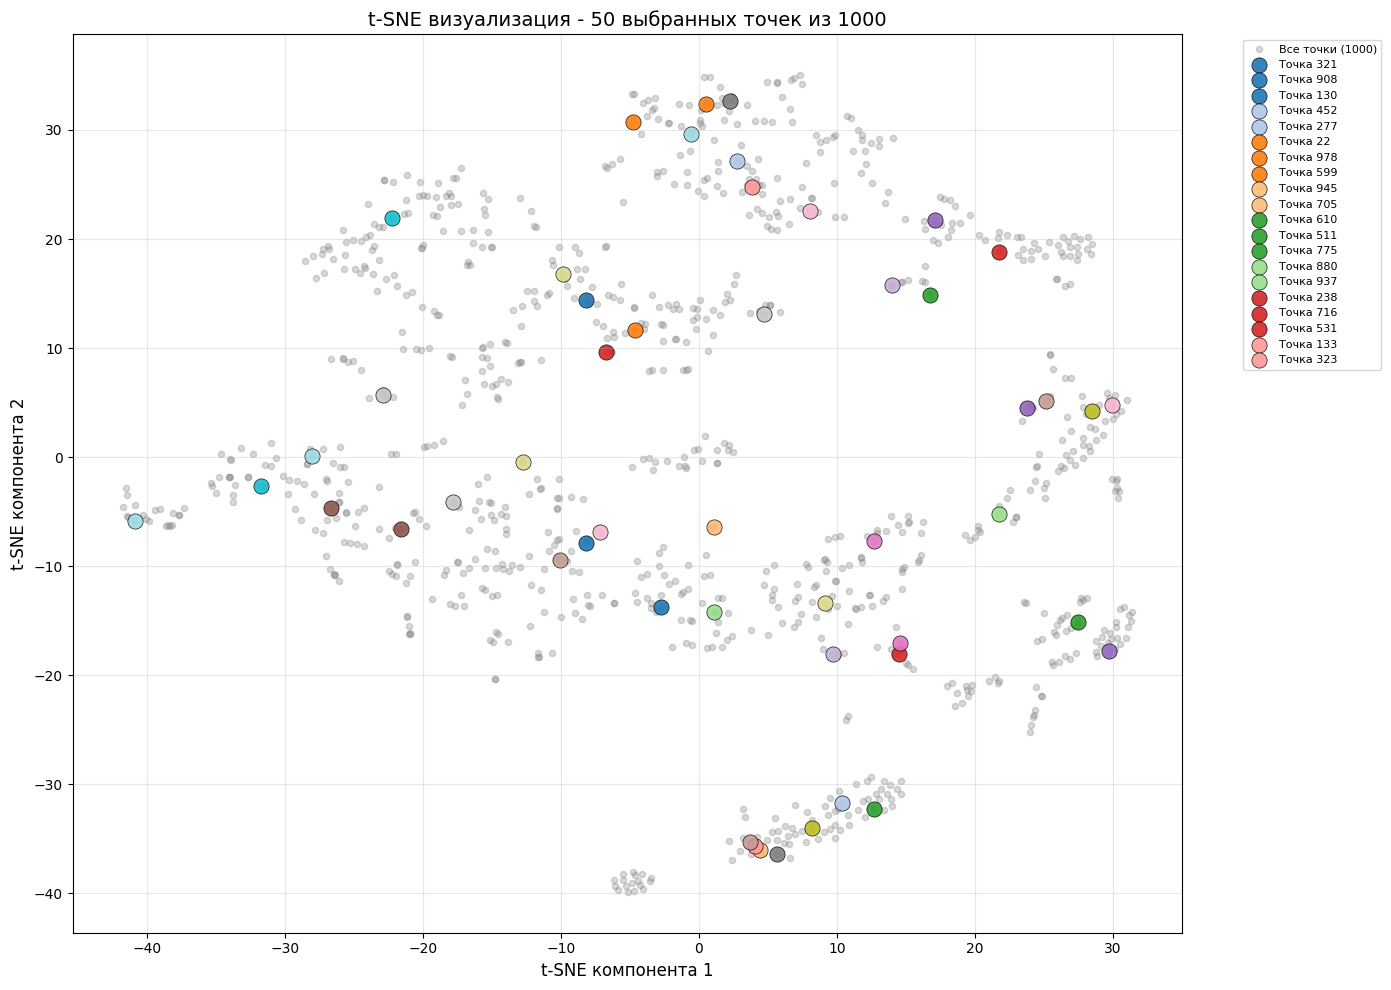

In [20]:
if isinstance(X, pd.DataFrame):
    X_array = X.values
else:
    X_array = X
sample_size = min(1000, len(X_array))
print(f"Берем подвыборку из {sample_size} точек")
np.random.seed(42)
sample_indices = np.random.choice(len(X_array), size=sample_size, replace=False)
X_sample = X_array[sample_indices]
print("Вычисляем t-SNE...")
tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000, verbose=1)
X_tsne = tsne.fit_transform(X_sample)
plt.figure(figsize=(14,10))
plt.scatter(
    X_tsne[:, 0],
    X_tsne[:, 1],
    c='gray',
    alpha=0.3,
    s=20,
    label=f'Все точки ({sample_size})'
)
n_vis = min(50, len(X_tsne))
vis_indices = np.random.choice(len(X_tsne), size=n_vis, replace=False)
colors = plt.cm.tab20(np.linspace(0, 1, n_vis))
for i, idx in enumerate(vis_indices):
    plt.scatter(
        X_tsne[idx, 0],
        X_tsne[idx, 1],
        color=colors[i],
        alpha=0.9,
        s=120,
        edgecolors='black',
        linewidth=0.5,
        label=f'Точка {idx}' if i < 20 else ""
    )
plt.xlabel("t-SNE компонента 1", fontsize=12)
plt.ylabel("t-SNE компонента 2", fontsize=12)
plt.title(f"t-SNE визуализация - {n_vis} выбранных точек из {sample_size}", fontsize=14)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

DBSCAN для кластеризации.

Берем подвыборку из 2000 точек для DBSCAN
Вычисляем DBSCAN...

Результаты DBSCAN:
Количество кластеров: 11
Количество шумовых точек: 1597 (79.8%)
Уникальные метки: [-1  0  1  2  3  4  5  6  7  8  9 10]


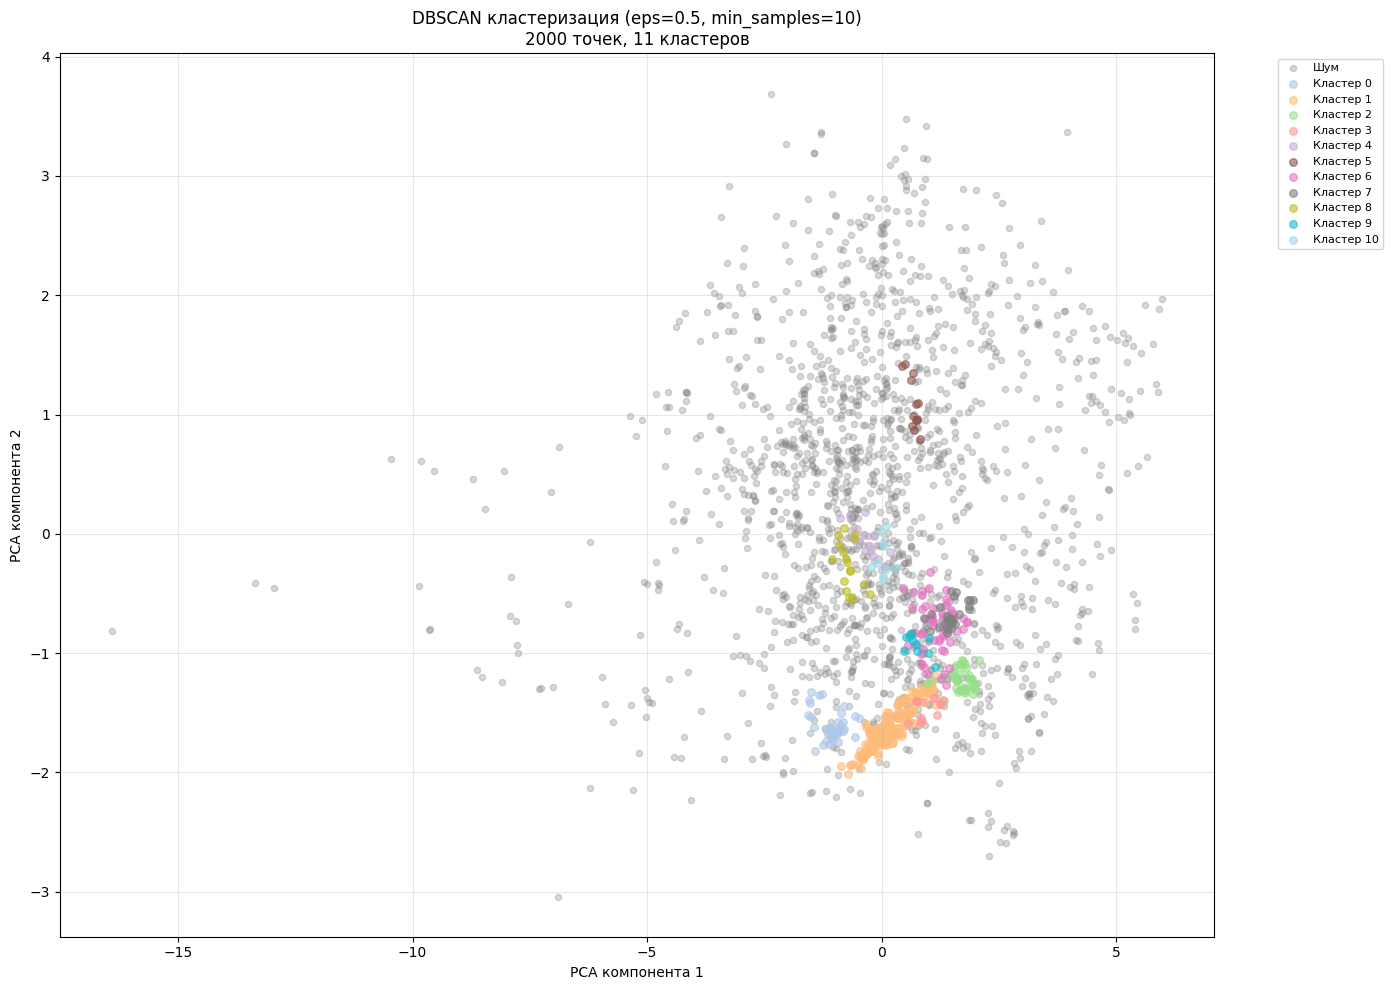

In [23]:
if isinstance(X, pd.DataFrame):
    X_array = X.values
else:
    X_array = X
sample_size = min(2000, len(X_array))
print(f"Берем подвыборку из {sample_size} точек для DBSCAN")
np.random.seed(42)
sample_indices = np.random.choice(len(X_array), size=sample_size, replace=False)
X_sample = X_array[sample_indices]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_sample)
print("Вычисляем DBSCAN...")
eps = 0.5
min_samples = 10
dbscan = DBSCAN(eps=eps, min_samples=min_samples, metric='euclidean')
labels = dbscan.fit_predict(X_scaled)
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = list(labels).count(-1)
print(f"\nРезультаты DBSCAN:")
print(f"Количество кластеров: {n_clusters}")
print(f"Количество шумовых точек: {n_noise} ({n_noise/len(labels)*100:.1f}%)")
print(f"Уникальные метки: {np.unique(labels)}")
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
plt.figure(figsize=(14,10))
unique_labels = np.unique(labels)
colors = plt.cm.tab20(np.linspace(0, 1, len(unique_labels)))
for label, color in zip(unique_labels, colors):
    if label == -1:
        plt.scatter(
            X_pca[labels == label, 0],
            X_pca[labels == label, 1],
            c='gray',
            alpha=0.3,
            s=20,
            label=f'Шум'
        )
    else:
        plt.scatter(
            X_pca[labels == label, 0],
            X_pca[labels == label, 1],
            c=[color],
            alpha=0.6,
            s=30,
            label=f'Кластер {label}'
        )
plt.xlabel("PCA компонента 1")
plt.ylabel("PCA компонента 2")
plt.title(f"DBSCAN кластеризация (eps={eps}, min_samples={min_samples})\n{sample_size} точек, {n_clusters} кластеров")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

DBSCAN для определения выбросов.

Берем подвыборку из 1000 точек для обнаружения выбросов
Вычисляем DBSCAN для поиска выбросов...

Результаты обнаружения выбросов:
Всего точек: 1000
Выбросы (шум): 856 (85.60%)
Нормальные точки: 144 (14.40%)
Количество кластеров: 10


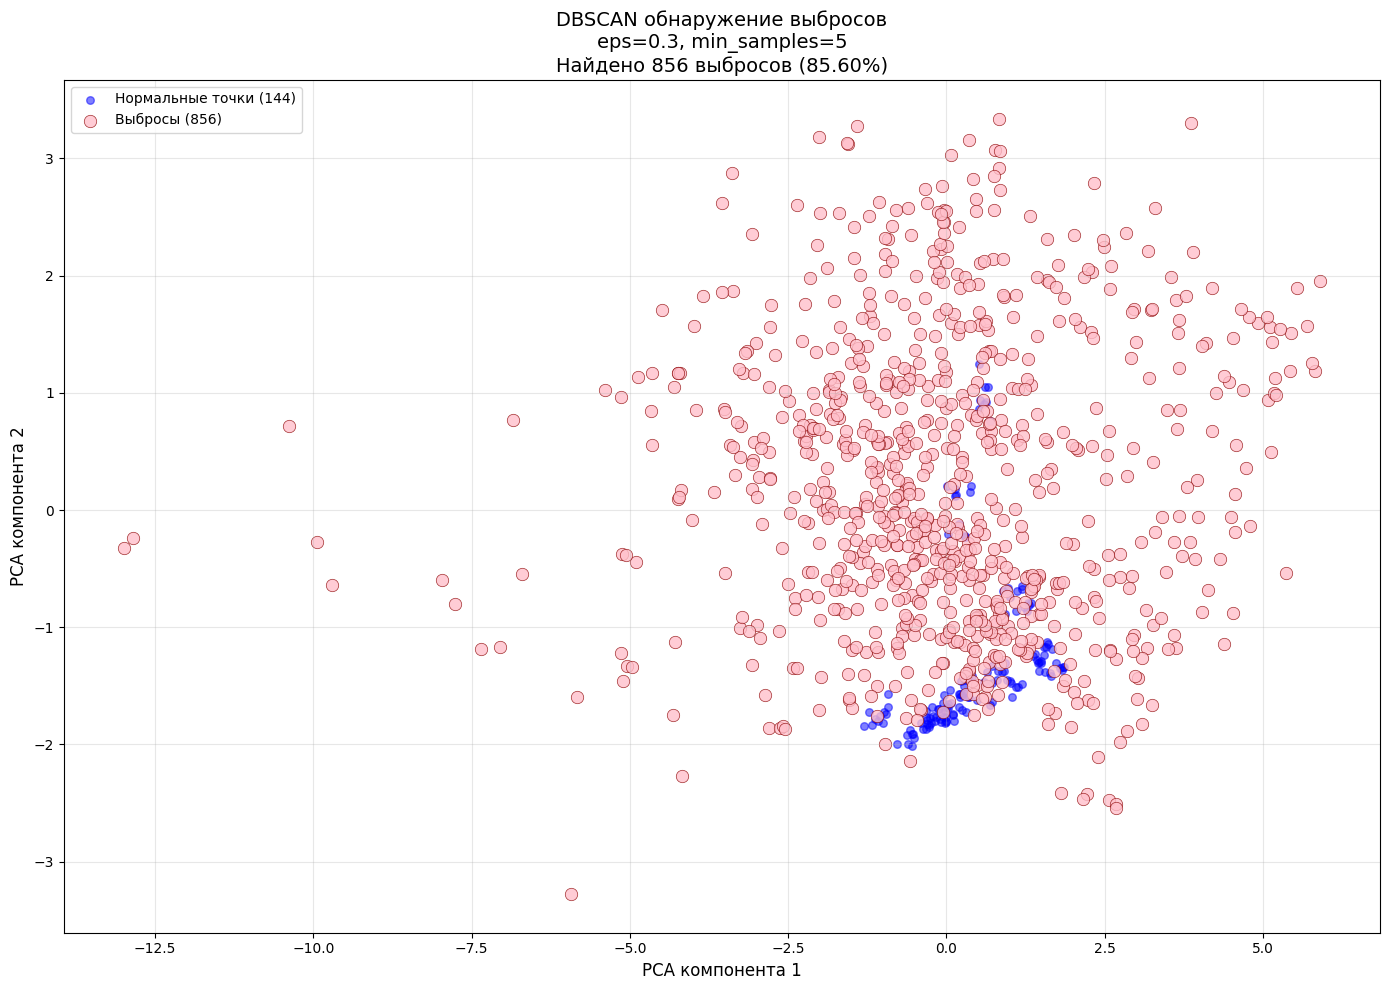

In [31]:
if isinstance(X, pd.DataFrame):
    X_array = X.values
else:
    X_array = X
sample_size = min(1000, len(X_array))
print(f"Берем подвыборку из {sample_size} точек для обнаружения выбросов")
np.random.seed(42)
sample_indices = np.random.choice(len(X_array), size=sample_size, replace=False)
X_sample = X_array[sample_indices]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_sample)
eps = 0.3
min_samples = 5
print("Вычисляем DBSCAN для поиска выбросов...")
dbscan = DBSCAN(eps=eps, min_samples=min_samples, metric='euclidean')
labels = dbscan.fit_predict(X_scaled)
n_outliers = list(labels).count(-1)
n_inliers = len(labels) - n_outliers
print(f"\nРезультаты обнаружения выбросов:")
print(f"Всего точек: {len(labels)}")
print(f"Выбросы (шум): {n_outliers} ({n_outliers/len(labels)*100:.2f}%)")
print(f"Нормальные точки: {n_inliers} ({n_inliers/len(labels)*100:.2f}%)")
print(f"Количество кластеров: {len(set(labels)) - (1 if -1 in labels else 0)}")
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
plt.figure(figsize=(14,10))
plt.scatter(
    X_pca[labels != -1, 0],
    X_pca[labels != -1, 1],
    c='blue',
    alpha=0.5,
    s=30,
    label=f'Нормальные точки ({n_inliers})'
)
plt.scatter(
    X_pca[labels == -1, 0],
    X_pca[labels == -1, 1],
    c='pink',
    alpha=0.8,
    s=80,
    edgecolors='darkred',
    linewidth=0.5,
    label=f'Выбросы ({n_outliers})'
)
outlier_indices = np.where(labels == -1)[0]
if len(outlier_indices) > 0:
    vis_outliers = np.random.choice(outlier_indices, size=min(50, len(outlier_indices)), replace=False)
plt.xlabel("PCA компонента 1", fontsize=12)
plt.ylabel("PCA компонента 2", fontsize=12)
plt.title(f"DBSCAN обнаружение выбросов\n"
          f"eps={eps}, min_samples={min_samples}\n"
          f"Найдено {n_outliers} выбросов ({n_outliers/len(labels)*100:.2f}%)",
          fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()